# Module 3B — NEV Fault Classifier (Local Training)

Train a four-class XGBoost model on `NEV_fault_dataset.csv`:

- `0`: normal
- `1`: motor fault
- `2`: inverter fault
- `3`: battery fault

The notebook uses the Module 3A loader, performs a stratified train/validation/test split, evaluates the model, and saves a complete inference bundle to `ml/models/engine_fault_clf.joblib`.

This is tabular ML, so CPU training is recommended and should finish quickly on this machine.

In [1]:
# Run once if your local environment is missing training dependencies:
# %pip install xgboost scikit-learn pandas matplotlib seaborn joblib

from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository:", REPO_ROOT)
print("Python:", sys.version)

Repository: F:\BMW
Python: 3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from ml.predictive_maintenance.config import (
    ENGINE_FAULT_MODEL_PATH,
    NEV_FAULT_CLASS_NAMES,
    NEV_FAULT_FEATURES,
    NEV_FAULT_PATH,
)
from ml.predictive_maintenance.datasets import prepare_engine_fault_frame

RANDOM_STATE = 42
print("Dataset:", NEV_FAULT_PATH)
print("Artifact:", ENGINE_FAULT_MODEL_PATH)
print("xgboost:", xgboost.__version__, "sklearn:", sklearn.__version__)

Dataset: F:\BMW\data\predictive_maintenance\NEV_fault_dataset.csv
Artifact: F:\BMW\ml\models\engine_fault_clf.joblib
xgboost: 3.3.0 sklearn: 1.9.0


In [3]:
data = prepare_engine_fault_frame()
X = data.X.astype(np.float32)
y = data.y.astype(np.int64)

print(f"Rows: {len(X):,}")
print("Features:", list(X.columns))
print("Target distribution:")
display(y.value_counts().sort_index().rename(index=dict(enumerate(NEV_FAULT_CLASS_NAMES))))
display(X.describe().T)

Rows: 11,000
Features: ['Voltage (V)', 'Current (A)', 'Motor Speed (RPM)', 'Temperature (°C)', 'Vibration (g)', 'Ambient Temp (°C)', 'Humidity (%)']
Target distribution:


Fault Label
normal            5000
motor_fault       2000
inverter_fault    2000
battery_fault     2000
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Voltage (V),11000.0,0.728576,0.224415,0.0,0.612900,0.797613,0.891521,1.0
Current (A),11000.0,0.431700,0.245215,0.0,0.237031,0.396222,0.604094,1.0
Motor Speed (RPM),11000.0,0.443010,0.256147,0.0,0.229121,0.413228,0.640606,1.0
Temperature (°C),11000.0,0.380225,0.229912,0.0,0.197145,0.370151,0.520455,1.0
Vibration (g),11000.0,0.281481,0.240546,0.0,0.109902,0.217818,0.345722,1.0
Ambient Temp (°C),11000.0,0.495347,0.286040,0.0,0.249639,0.490943,0.743677,1.0
Humidity (%),11000.0,0.500356,0.290172,0.0,0.246695,0.503985,0.749887,1.0


## Leakage-safe split

Reserve 20% as a final untouched test set. Split the remaining 80% into training and validation sets. All splits are stratified because the normal class has more samples than each fault class.

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print("train:", X_train.shape, "validation:", X_val.shape, "test:", X_test.shape)
for name, labels in (("train", y_train), ("validation", y_val), ("test", y_test)):
    print(name, labels.value_counts(normalize=True).sort_index().round(3).to_dict())

train: (7040, 7) validation: (1760, 7) test: (2200, 7)
train {0: 0.455, 1: 0.182, 2: 0.182, 3: 0.182}
validation {0: 0.455, 1: 0.182, 2: 0.182, 3: 0.182}
test {0: 0.455, 1: 0.182, 2: 0.182, 3: 0.182}


## Train XGBoost

The model uses the multiclass soft-probability objective so runtime inference receives calibrated class probabilities. Early stopping uses only the validation split. No feature scaling is needed for tree boosting.

In [5]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(NEV_FAULT_CLASS_NAMES),
    n_estimators=700,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_alpha=0.05,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    early_stopping_rounds=40,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

print("Best iteration:", model.best_iteration)
print("Best validation mlogloss:", model.best_score)

Best iteration: 265
Best validation mlogloss: 0.01306647119029714


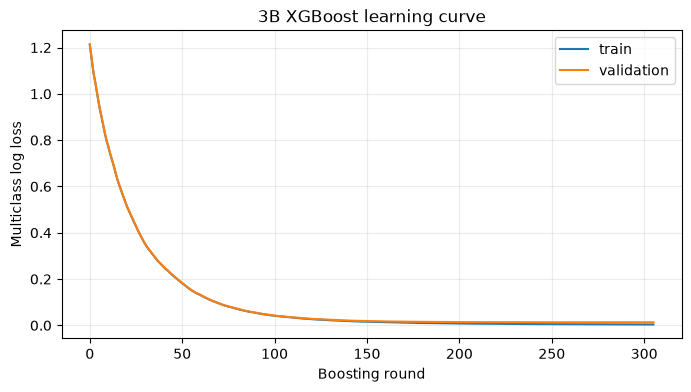

In [6]:
history = model.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(history["validation_0"]["mlogloss"], label="train")
plt.plot(history["validation_1"]["mlogloss"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("Multiclass log loss")
plt.title("3B XGBoost learning curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Final test evaluation

Run this only after model selection. The macro F1 score gives equal importance to normal, motor, inverter, and battery classes.

{'accuracy': 0.9931818181818182, 'macro_f1': 0.9906238133263741, 'weighted_f1': 0.9931809551464539, 'log_loss': 0.0189931970089674}
                precision    recall  f1-score   support

        normal     1.0000    1.0000    1.0000      1000
   motor_fault     1.0000    1.0000    1.0000       400
inverter_fault     0.9707    0.9925    0.9815       400
 battery_fault     0.9923    0.9700    0.9810       400

      accuracy                         0.9932      2200
     macro avg     0.9907    0.9906    0.9906      2200
  weighted avg     0.9933    0.9932    0.9932      2200



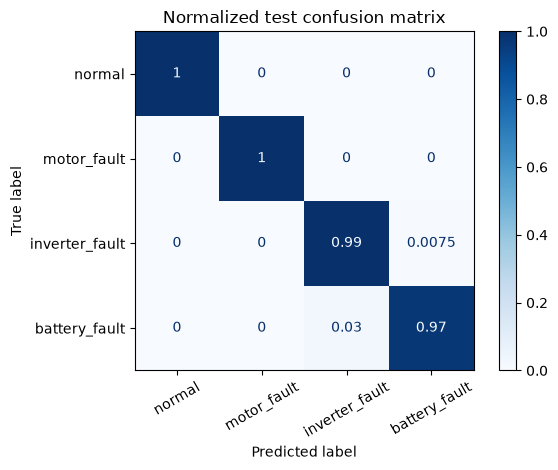

In [7]:
test_probabilities = model.predict_proba(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

metrics = {
    "accuracy": float(accuracy_score(y_test, test_predictions)),
    "macro_f1": float(f1_score(y_test, test_predictions, average="macro")),
    "weighted_f1": float(f1_score(y_test, test_predictions, average="weighted")),
    "log_loss": float(log_loss(y_test, test_probabilities, labels=range(len(NEV_FAULT_CLASS_NAMES)))),
}
print(metrics)
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=NEV_FAULT_CLASS_NAMES,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=NEV_FAULT_CLASS_NAMES,
    normalize="true",
    xticks_rotation=30,
    cmap="Blues",
)
plt.title("Normalized test confusion matrix")
plt.tight_layout()
plt.show()

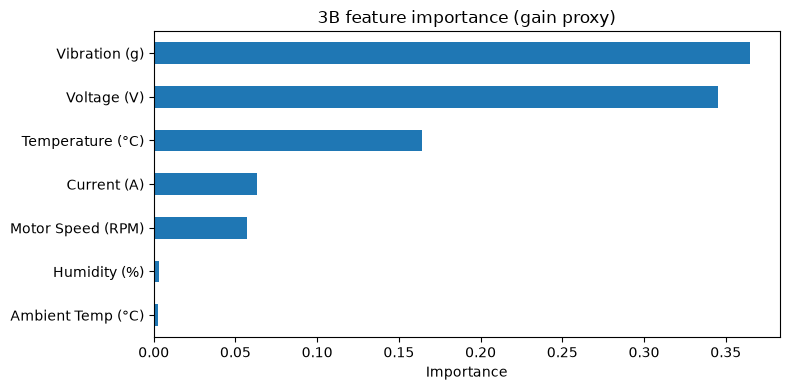

,importance
Vibration (g),0.364945
Voltage (V),0.345173
Temperature (°C),0.164156
Current (A),0.062893
Motor Speed (RPM),0.057061
Humidity (%),0.003128
Ambient Temp (°C),0.002644


In [8]:
importance = pd.Series(model.feature_importances_, index=NEV_FAULT_FEATURES).sort_values()
importance.plot.barh(figsize=(8, 4), title="3B feature importance (gain proxy)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
display(importance.sort_values(ascending=False).to_frame("importance"))

## Save the inference bundle

The `.joblib` bundle includes the trained model, exact feature order, class names, dataset metadata, versions, and final test metrics. The runtime wrapper validates this contract before inference.

In [9]:
from datetime import datetime, timezone

ENGINE_FAULT_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
bundle = {
    "schema_version": 1,
    "module": "3B",
    "task": "nev_multiclass_fault_classification",
    "model": model,
    "features": list(NEV_FAULT_FEATURES),
    "class_names": list(NEV_FAULT_CLASS_NAMES),
    "metrics": metrics,
    "dataset": str(NEV_FAULT_PATH),
    "rows": int(len(X)),
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "versions": {
        "xgboost": xgboost.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}
joblib.dump(bundle, ENGINE_FAULT_MODEL_PATH)
print(f"Saved {ENGINE_FAULT_MODEL_PATH} ({ENGINE_FAULT_MODEL_PATH.stat().st_size / 1024:.1f} KiB)")

Saved F:\BMW\ml\models\engine_fault_clf.joblib (1358.2 KiB)


In [10]:
# Reload through the production 3B wrapper and test one held-out sample.
from ml.predictive_maintenance.engine_model import EngineFaultClassifier

runtime = EngineFaultClassifier(model_path=ENGINE_FAULT_MODEL_PATH)
result = runtime.predict(X_test.iloc[0].to_dict())
print("Expected:", NEV_FAULT_CLASS_NAMES[int(y_test.iloc[0])])
print("Predicted:", result)
assert result.class_id in range(len(NEV_FAULT_CLASS_NAMES))
assert abs(sum(result.probabilities.values()) - 1.0) < 1e-5
print("3B artifact reload and inference check passed.")

Expected: inverter_fault
Predicted: EngineFaultResult(class_id=2, class_name='inverter_fault', confidence=0.8525102734565735, probabilities={'normal': 0.0041013979353010654, 'motor_fault': 0.0009683375246822834, 'inverter_fault': 0.8525102734565735, 'battery_fault': 0.14242000877857208}, fault_detected=True)
3B artifact reload and inference check passed.
